In [1]:
import sys
import json
sys.path.append('..')
from Main.Experiment_class import *
from Utils.theoretical_points import *
from copy import deepcopy

In [2]:
markersize = 15
capsize = 6
capthick = 2
linewidth = 7.5
elinewidth=2

In [3]:
obj = PIcode_experiment(None, False, False)
obj.load('../Data/31st_August_Torino_run1.json')
N = obj.storage['multi_qec_30_1']['shots']
rec_time = obj.recovery_time*obj.dt/1e3
enc_time = obj.encoder_time*obj.dt/1e3

In [4]:
objsim = PIcode_experiment(None, False, False)
objsim.load('../Data/T290_simulation.json')

In [5]:
delays_th = np.linspace(0, 300, 601)
th_data = get_th_approx_data(200, 90, delays_th, 30)

In [6]:
delays_multi = np.array(obj.storage['bare_qubit']['delays'])
relaxation_time = 30
for i in range(len(delays_multi)):
    t = int(np.ceil(delays_multi[i]/30))
    if t  == 0:
        t = 1
    delays_multi[i] += t*rec_time
delays_multi += 2*enc_time

# 1L

In [7]:
index = 6
p_approx_1 = th_data['multi_qec_1_approx']['probs']
p_sim_1 = objsim.storage[f'multi_qec_30_1']['success_rates']['0']
p_exp_1 = obj.storage[f'multi_qec_30_1']['success_rates'][f'{index}']
delays = obj.storage[f'multi_qec_30_1']['delays']

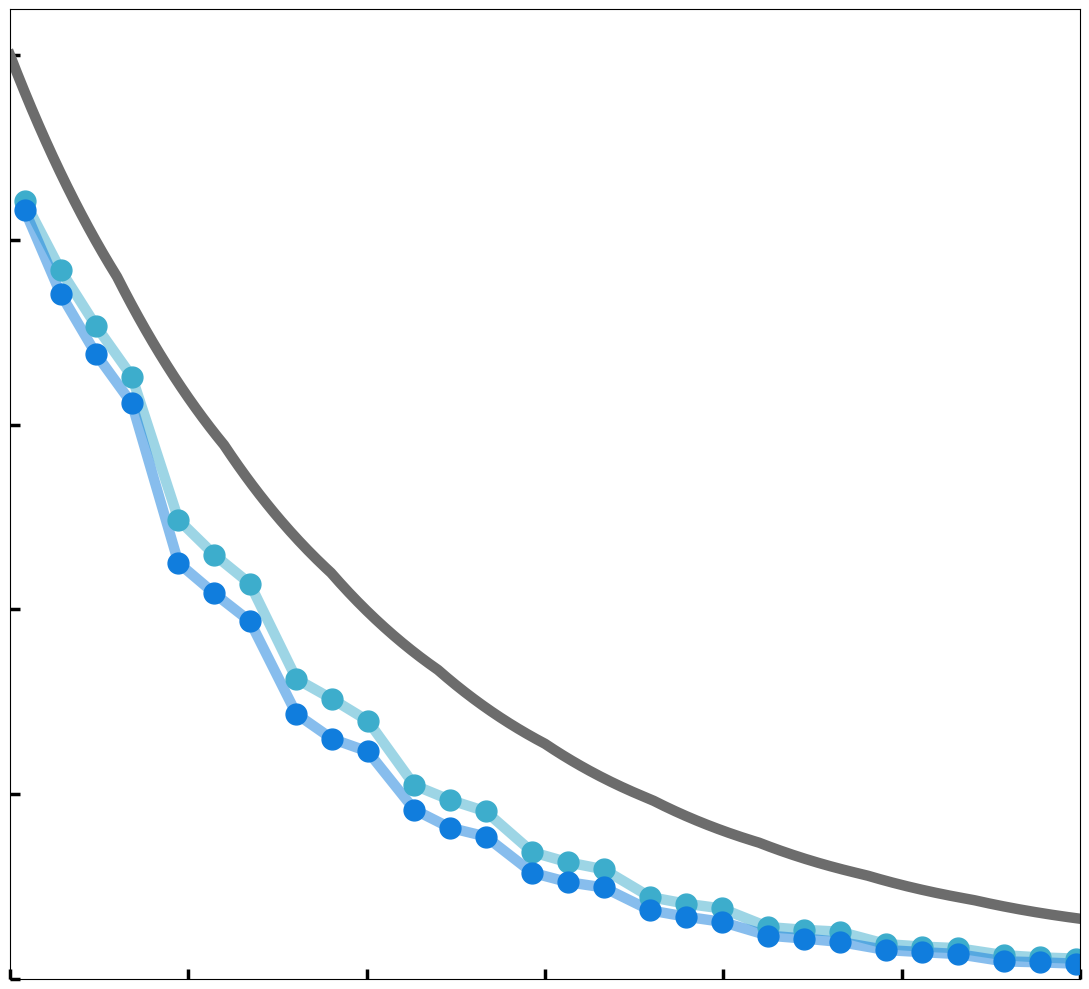

In [8]:
plt.figure(figsize=(11,10))

plt.errorbar(delays_multi, p_sim_1, yerr=None, 
            fmt='o', color='#3DADCC', ecolor = '#3DADCC', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'Simulation', ls = None)
plt.plot(delays_multi, p_sim_1, color='#3DADCC', linewidth = linewidth, alpha = 0.5)

plt.errorbar(delays_multi, p_exp_1, yerr=None, 
            fmt='o', color='#107DDD', ecolor = '#107DDD', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'Experimental', ls = None)
plt.plot(delays_multi, p_exp_1, color='#107DDD', linewidth = linewidth, alpha = 0.5)
plt.plot(delays_th, p_approx_1, label=r'Theoretical', c = "#6C6C6C", ls = '-', lw = linewidth)
plt.xlim(0, 300)
plt.ylim(0, 1.05)
plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.legend(loc = 'upper right', frameon = False, fontsize = 24)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel('Probability', fontsize = 24)
plt.tight_layout()
plt.savefig('fig8_b_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# 0L

In [10]:
index = 6
p_approx_0 = th_data['multi_qec_0_approx']['probs']
p_sim_0 = objsim.storage[f'multi_qec_30_0']['success_rates']['0']
p_exp_0 = obj.storage[f'multi_qec_30_0']['success_rates'][f'{index}']
delays = obj.storage[f'multi_qec_30_0']['delays']

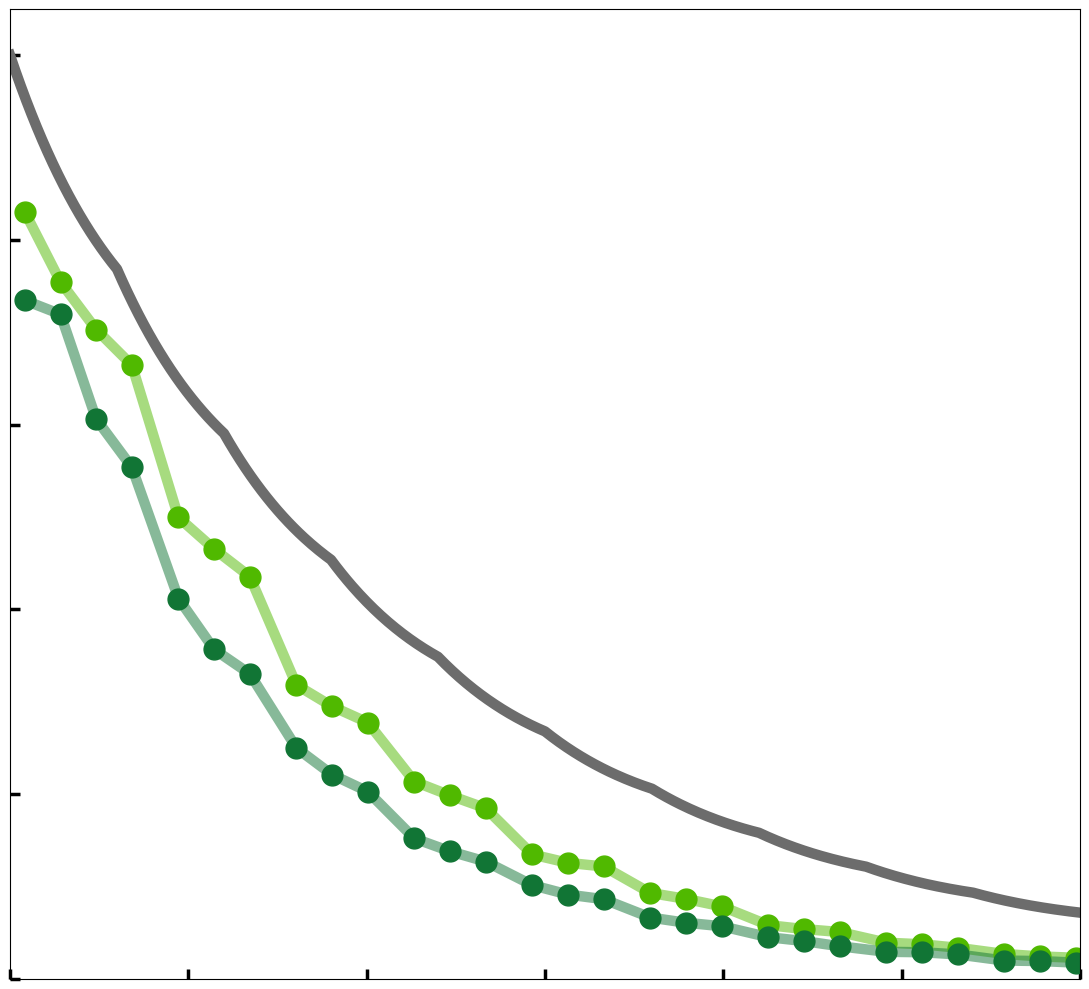

In [11]:
plt.figure(figsize=(11,10))

plt.errorbar(delays_multi, p_sim_0, yerr=None, 
            fmt='o', color='#50B900', ecolor = '#50B900', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'Simulation', ls = None)
plt.plot(delays_multi, p_sim_0, color="#50B900", linewidth = linewidth, alpha = 0.5)

plt.errorbar(delays_multi, p_exp_0, yerr=None, 
            fmt='o', color='#117535', ecolor = '#117535', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'Experimental', ls = None)
plt.plot(delays_multi, p_exp_0, color='#117535', linewidth = linewidth, alpha = 0.5)
plt.plot(delays_th, p_approx_0, label=r'Theoretical', c = "#6C6C6C", ls = '-', lw = linewidth)
plt.xlim(0, 300)
plt.ylim(0, 1.05)
plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.legend(loc = 'upper right', frameon = False, fontsize = 24)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel('Probability', fontsize = 24)
plt.tight_layout()
plt.savefig('fig8_a_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)